In [1]:
%matplotlib widget

# Plot comparisons

In [2]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

In [3]:
model_true = np.load('models/model_3DChannel_new.npy')
model_true[:,:,1:] = model_true[:,:,1:]*1000
model_true_grid = np.load('models/model_true_grid.npy')

model_LCI = np.load('models/model_LCI_Channel.npy')
model_PW = np.load('models/model_PW_Channel.npy')

model_LCI_grid = np.load('models/model_LCI_Channel_grid.npy')
model_PW_grid = np.load('models/model_PW_Channel_grid.npy')

# Plot Lines

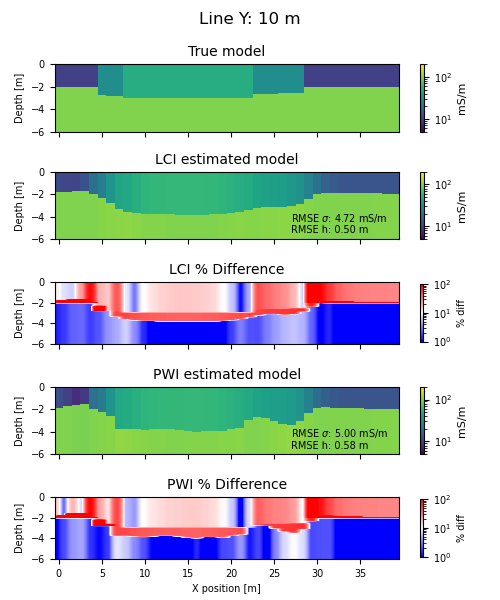

In [11]:
fig, ax = plt.subplots(5, figsize=(5,6), sharex=True)

l = 10
fs = 7
fs2 = 10
showStitchedModels(model_true[:,l,:], zMax= 6, cMin=5, cMax=200, ax=ax[0], label='mS/m')
ax[0].set_title('True model', fontsize=fs2)
ax[0].set_ylabel('Depth [m]', fontsize=fs)
ax[0].tick_params(labelsize=fs)

showStitchedModels(model_LCI[l,:,:], zMax= 6, cMin=5, cMax=200, ax=ax[1], label='mS/m')
ax[1].set_title('LCI estimated model', fontsize=fs2)
ax[1].set_ylabel('Depth [m]', fontsize=fs)
ax[1].text(27,-4.5, 'RMSE $\sigma$: %2.2f' %root_mean_squared_error(model_true[:,l,1:], model_LCI[l,:,1:]) + ' mS/m', fontsize=fs)
ax[1].text(27,-5.5, 'RMSE h: %2.2f' %root_mean_squared_error(model_true[:,l,0], model_LCI[l,:,0]) + ' m', fontsize=fs)
ax[1].tick_params(labelsize=fs)

c2 = ax[2].imshow(np.abs((model_LCI_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([-1, 40,-6,0]), cmap='bwr', aspect=1.2, norm='log', vmin=1, vmax=100)
cb = fig.colorbar(c2, ax=ax[2], label='mS/m', shrink=0.85)
cb.ax.tick_params(labelsize=fs)
cb.ax.set_ylabel('% diff', fontsize=fs)
ax[2].set_title('LCI % Difference', fontsize=fs2)
ax[2].set_ylabel('Depth [m]', fontsize=fs)
ax[2].tick_params(labelsize=fs)

showStitchedModels(model_PW[l,:,:], zMax= 6, cMin=5, cMax=200, ax=ax[3], label='mS/m')
ax[3].set_title('PWI estimated model', fontsize=fs2)
ax[3].set_ylabel('Depth [m]', fontsize=fs)
ax[3].text(27,-4.5, 'RMSE $\sigma$: %2.2f' %root_mean_squared_error(model_true[:,l,1:], model_PW[l,:,1:]) + ' mS/m', fontsize=fs)
ax[3].text(27,-5.5, 'RMSE h: %2.2f' %root_mean_squared_error(model_true[:,l,0], model_PW[l,:,0]) + ' m', fontsize=fs)
ax[3].tick_params(labelsize=fs)

c2 = ax[4].imshow(np.abs((model_PW_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([-1, 40,-6,0]), cmap='bwr', aspect=1.2, norm='log', vmin=1, vmax=100 )
cb= fig.colorbar(c2, ax=ax[4], label='mS/m', shrink=0.85)
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4].set_title('PWI % Difference', fontsize=fs2)
ax[4].set_ylabel('Depth [m]', fontsize=fs)
ax[4].set_xlabel('X position [m]', fontsize=fs)
ax[4].tick_params(labelsize=fs)

fig.suptitle('Line Y: '+str( l) + ' m')

plt.tight_layout()

In [5]:
# Plot Maps

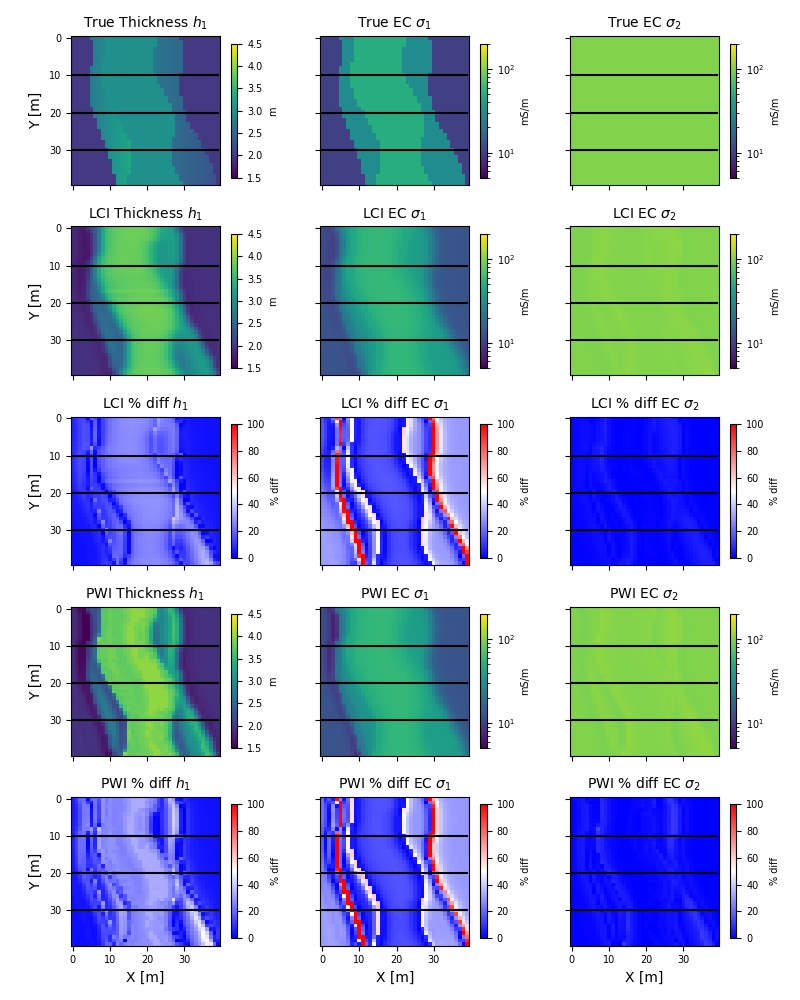

In [6]:
fig, ax = plt.subplots(5,3, figsize=(8,10), sharex=True, sharey=True)

s=0.9
fs=7
fs2=10

vmin=5
vmax=200

c1 = ax[0,0].imshow(model_true[:,:,0].T, vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[0,0],  shrink=s, )
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)


ax[0,0].tick_params(labelsize=fs)
ax[0,0].set_title('True Thickness $h_1$', fontsize=fs2)
ax[0,0].set_ylabel('Y [m]', fontsize=fs2)
ax[0,0].plot([0,39], [10,10],'k')
ax[0,0].plot([0,39], [20,20],'k')
ax[0,0].plot([0,39], [30,30],'k')

c1 = ax[1,0].imshow(model_LCI[:,:,0], vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[1,0], shrink=s)
ax[1,0].set_title('LCI Thickness $h_1$', fontsize=fs2)
ax[1,0].set_ylabel('Y [m]', fontsize=fs2)
ax[1,0].plot([0,39], [10,10],'k')
ax[1,0].plot([0,39], [20,20],'k')
ax[1,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,0].tick_params(labelsize=fs)

c1 = ax[2,0].imshow((np.abs(model_true[:,:,0].T - model_LCI[:,:,0])/model_true[:,:,0].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[2,0], shrink=s)
ax[2,0].set_title('LCI % diff $h_1$', fontsize=fs2)
ax[2,0].set_ylabel('Y [m]', fontsize=fs2)
ax[2,0].plot([0,39],[10,10],'k')
ax[2,0].plot([0,39],[20,20], 'k')
ax[2,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,0].tick_params(labelsize=fs)

c1 = ax[3,0].imshow(model_PW[:,:,0], vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[3,0],  shrink=s)
ax[3,0].set_title('PWI Thickness $h_1$', fontsize=fs2)
ax[3,0].set_ylabel('Y [m]', fontsize=fs2)
ax[3,0].plot([0,39], [10,10],'k')
ax[3,0].plot([0,39], [20,20],'k')
ax[3,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,0].tick_params(labelsize=fs)

c1 = ax[4,0].imshow((np.abs(model_true[:,:,0].T - model_PW[:,:,0])/model_true[:,:,0].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[4,0], shrink=s)
ax[4,0].set_title('PWI % diff $h_1$', fontsize=fs2)
ax[4,0].set_ylabel('Y [m]', fontsize=fs2)
ax[4,0].set_xlabel('X [m]', fontsize=fs2)
ax[4,0].plot([0,39], [10,10],'k')
ax[4,0].plot([0,39], [20,20],'k')
ax[4,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4,0].tick_params(labelsize=fs)

c2 = ax[0,1].imshow(model_true[:,:,1].T, vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[0,1],  shrink=s)
ax[0,1].set_title('True EC $\sigma_1$', fontsize=fs2)
ax[0,1].plot([0,39], [10,10],'k')
ax[0,1].plot([0,39], [20,20],'k')
ax[0,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[0,1].tick_params(labelsize=fs)

c2 = ax[1,1].imshow(model_LCI[:,:,1], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[1,1],  shrink=s)
ax[1,1].set_title('LCI EC $\sigma_1$', fontsize=fs2)
ax[1,1].plot([0,39], [10,10],'k')
ax[1,1].plot([0,39], [20,20],'k')
ax[1,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,1].tick_params(labelsize=fs)

c1 = ax[2,1].imshow((np.abs(model_true[:,:,1].T - model_LCI[:,:,1])/model_true[:,:,1].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[2,1],  shrink=s)
ax[2,1].set_title('LCI % diff EC $\sigma_1$', fontsize=fs2)
ax[2,1].plot([0,39], [10,10],'k')
ax[2,1].plot([0,39], [20,20],'k')
ax[2,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,1].tick_params(labelsize=fs)

c2 = ax[3,1].imshow(model_PW[:,:,1], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[3,1],  shrink=s)
ax[3,1].set_title('PWI EC $\sigma_1$', fontsize=fs2)
ax[3,1].plot([0,39], [10,10],'k')
ax[3,1].plot([0,39], [20,20],'k')
ax[3,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,1].tick_params(labelsize=fs)

c1 = ax[4,1].imshow((np.abs(model_true[:,:,1].T - model_PW[:,:,1])/model_true[:,:,1].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[4,1],  shrink=s)
ax[4,1].set_title('PWI % diff EC $\sigma_1$', fontsize=fs2)
ax[4,1].set_xlabel('X [m]')
ax[4,1].plot([0,39], [10,10],'k')
ax[4,1].plot([0,39], [20,20],'k')
ax[4,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4,1].tick_params(labelsize=fs)

c3 = ax[0,2].imshow(model_true[:,:,2].T, vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c3, ax=ax[0,2],  shrink=s)
ax[0,2].set_title('True EC $\sigma_2$', fontsize=fs2)
ax[0,2].plot([0,39], [10,10],'k')
ax[0,2].plot([0,39], [20,20],'k')
ax[0,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[0,2].tick_params(labelsize=fs)

c3 = ax[1,2].imshow(model_LCI[:,:,2], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c3, ax=ax[1,2],  shrink=s)
ax[1,2].set_title('LCI EC $\sigma_2$', fontsize=fs2)
ax[1,2].plot([0,39], [10,10], 'k')
ax[1,2].plot([0,39], [20,20],'k')
ax[1,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,2].tick_params(labelsize=fs)

c1 = ax[2,2].imshow((np.abs(model_true[:,:,2].T - model_LCI[:,:,2])/model_true[:,:,2].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[2,2],  shrink=s)
ax[2,2].set_title('LCI % diff EC $\sigma_2$', fontsize=fs2)
ax[2,2].plot([0,39], [10,10],'k')
ax[2,2].plot([0,39], [20,20],'k')
ax[2,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,2].tick_params(labelsize=fs)

c3 = ax[3,2].imshow(model_PW[:,:,2], vmin =vmin, vmax=vmax, norm='log')
cb  = fig.colorbar(c3, ax=ax[3,2],  shrink=s)
ax[3,2].set_title('PWI EC $\sigma_2$', fontsize=fs2)
ax[3,2].plot([0,39], [10,10],'k')
ax[3,2].plot([0,39], [20,20],'k')
ax[3,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,2].tick_params(labelsize=fs)

c1 = ax[4,2].imshow((np.abs(model_true[:,:,2].T - model_PW[:,:,2])/model_true[:,:,2].T)*100, vmin=0, vmax=100, cmap='bwr')
cb = fig.colorbar(c1, ax=ax[4,2], shrink=s)
ax[4,2].set_title('PWI % diff EC $\sigma_2$', fontsize=fs2)
ax[4,2].set_xlabel('X [m]')
ax[4,2].plot([0,39], [10,10],'k')
ax[4,2].plot([0,39], [20,20],'k')
ax[4,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs, )
cb.ax.tick_params(labelsize=fs)
ax[4,2].tick_params(labelsize=fs)

plt.tight_layout()